# Lecture 3d — Portfolio Stability and the Condition Number

### The question

You run an optimiser on Monday and get a portfolio. On Tuesday you add one more day of data —
one day out of 252 — and re-run it. How much should the portfolio change?

The honest answer, for a lot of real optimisers, is: **completely**. Positions flip from long
to short. Weights double. A stock at 15% disappears entirely. Nothing about the world changed
in that single day, but your portfolio is unrecognisable.

That is **instability**, and it is not a bug in the optimiser. It is a measurable, predictable
property of your covariance matrix, and there is a single number that tells you how bad it
will be before you ever run the optimisation:

$$\kappa(\Sigma) = \frac{\lambda_{\max}}{\lambda_{\min}}$$

The **condition number**. Most treatments print it and move on. We are going to show that it
is something far more useful than a diagnostic statistic:

> **The condition number is the exchange rate between error in your data and error in your
> portfolio.**

A κ of 300 means a 1% error in your covariance estimate can become a 300% error in your
weights. That is not a metaphor. It is a theorem from numerical analysis, it has a provable
bound, and by the end of this notebook you will have measured it happening.

### What you will be able to do afterwards

1. Compute a condition number correctly, and explain what it means **geometrically**.
2. Predict how unstable a portfolio will be *before* optimising, from κ alone.
3. Explain why the **direction** of an estimation error matters more than its size.
4. Identify the $N/T$ regime in which a covariance matrix stops being invertible at all.
5. Measure real portfolio instability through time, and distinguish the **two different
   mechanisms** by which shrinkage and constraints fix it.

This notebook is a companion to Lecture 3c. Where 3c asked *"do these methods improve
returns?"*, this one asks *"do they make the portfolio hold still?"* — a different question
with a different answer.

---

## 0. Setup

Default data is the cached public dataset used throughout Lecture 3, so nothing depends on a
live connection during class. If you would rather pull fresh data, set `USE_YFINANCE = True`
and edit the ticker list — everything downstream works either way.

The key parameter is `N_STOCKS`. Almost everything in this notebook is about how stability
degrades as the universe grows relative to the sample, so we build a universe of *variable
size* and vary it deliberately.

In [1]:
# =====================================================================
#  AIRM Lecture 3d — bootstrap.  Run once.
# =====================================================================
import sys, subprocess, urllib.request, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

def _has(p):
    try: __import__({"scikit-learn": "sklearn", "riskfolio-lib": "riskfolio"}.get(p, p)); return True
    except ImportError: return False
def ensure(pkgs):
    missing = [p for p in pkgs if not _has(p)]
    if missing:
        print(f"Installing {', '.join(missing)} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

ensure(["pandas", "numpy", "plotly", "scipy"])

HAS_RISKFOLIO = True
try:
    ensure(["riskfolio-lib"]); import riskfolio as rp
except Exception:
    HAS_RISKFOLIO = False
    print("Riskfolio-Lib unavailable — Module F falls back to a hand-coded shrinkage estimator.")

import numpy as np, pandas as pd
from scipy.optimize import minimize
from scipy import stats as sps
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB: pio.renderers.default = "colab"
np.random.seed(3)

AIRM_TEMPLATE = "plotly_white"
AIRM_COLOURS  = ["#1b4965", "#c1121f", "#5fa8d3", "#e09f3e", "#606c38", "#8e7dbe"]
TRADING_DAYS  = 252

# --------------------------------------------------------------------
USE_YFINANCE = False        # set True to pull live data instead
YF_TICKERS   = ["AAPL", "MSFT", "AMZN", "GOOGL", "CVX",
                "TSLA", "BRK-B", "JPM", "JNJ", "WMT"]
YF_START, YF_END = "2018-01-01", "2023-12-31"
# --------------------------------------------------------------------

if USE_YFINANCE:
    ensure(["yfinance"]); import yfinance as yf
    _px = yf.download(YF_TICKERS, start=YF_START, end=YF_END, auto_adjust=True)["Close"]
    if isinstance(_px.columns, pd.MultiIndex):        # yfinance changed this in 2024
        _px.columns = _px.columns.get_level_values(-1)
    prices_all = _px.dropna(axis=1, how="any")
    SECTOR = {t: "Unclassified" for t in prices_all.columns}
    print(f"yfinance: {prices_all.shape[1]} tickers, {len(prices_all)} days")
else:
    DATA_DIR = Path("airm_data"); DATA_DIR.mkdir(exist_ok=True)
    SOURCES = {
        "prices.csv":       "https://raw.githubusercontent.com/plotly/datasets/master/all_stocks_5yr.csv",
        "constituents.csv": "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/main/data/constituents.csv",
    }
    def fetch(name):
        path = DATA_DIR / name
        if not path.exists():
            print(f"Downloading {name} ...", end=" ")
            urllib.request.urlretrieve(SOURCES[name], path); print("done")
        return path
    _raw = pd.read_csv(fetch("prices.csv"), parse_dates=["date"]).rename(columns={"Name": "ticker"})
    _con = pd.read_csv(fetch("constituents.csv"))
    prices_all = _raw.pivot_table(index="date", columns="ticker", values="close")
    SECTOR = _con.set_index("Symbol")["GICS Sector"].to_dict()
    _liq = _raw.groupby("ticker")["volume"].mean()

print(f"\nPrice panel: {prices_all.shape[1]} names, {len(prices_all)} days")


Price panel: 505 names, 1259 days


In [2]:
def build_universe(n_stocks, sector_balanced=True):
    """Return a list of `n_stocks` tickers, spread evenly across sectors where possible.

    Universe SIZE is the main experimental variable in this notebook, so this is written
    to be called repeatedly with different n.
    """
    eligible = [t for t in prices_all.columns if prices_all[t].notna().all()]
    if not sector_balanced or len(set(SECTOR.get(t, "?") for t in eligible)) < 2:
        ranked = _liq[eligible].nlargest(n_stocks).index.tolist() if not USE_YFINANCE \
                 else eligible[:n_stocks]
        return sorted(ranked)

    sectors = sorted({SECTOR[t] for t in eligible if t in SECTOR})
    per = int(np.ceil(n_stocks / len(sectors)))
    picked = []
    for s in sectors:
        names = [t for t in eligible if SECTOR.get(t) == s]
        picked += list(_liq[names].nlargest(per).index)
    picked = sorted(picked, key=lambda t: (SECTOR.get(t, "?"), t))
    return picked[:n_stocks]


def get_returns(tickers, n_days=None):
    """Daily returns for a ticker list, optionally the most recent n_days."""
    r = prices_all[list(tickers)].pct_change(fill_method=None).dropna()
    return r if n_days is None else r.iloc[-n_days:]


MAX_N = len(build_universe(10_000))
print(f"Maximum universe available: {MAX_N} stocks")
print(f"Maximum sample length     : {len(prices_all)} days\n")
for n in [10, 44, 100, 200]:
    if n <= MAX_N:
        print(f"  N = {n:3d} over 252 days -> T/N = {252/n:5.2f}")

Maximum universe available: 334 stocks
Maximum sample length     : 1259 days

  N =  10 over 252 days -> T/N = 25.20
  N =  44 over 252 days -> T/N =  5.73
  N = 100 over 252 days -> T/N =  2.52
  N = 200 over 252 days -> T/N =  1.26


### One correction before we start

The natural way to write a condition number is `np.linalg.eigvals(S)` and take the ratio of
largest to smallest. **Use `eigvalsh` instead.** A covariance matrix is symmetric, and:

- `eigvals` is the general (non-symmetric) routine. It can return eigenvalues with tiny
  spurious imaginary parts from floating-point round-off — so you end up wrapping everything
  in `np.abs()`, which silently hides the fact that something went wrong.
- `eigvalsh` exploits symmetry, guarantees **real** eigenvalues, returns them sorted, and is
  roughly twice as fast.

For a matrix you are about to invert and bet money on, "silently hides that something went
wrong" is not a property you want.

In [3]:
# def condition_number(S):
#     """kappa = largest / smallest eigenvalue, using the SYMMETRIC eigensolver.

#     Returns np.inf if the matrix is singular (smallest eigenvalue at or below zero),
#     which happens whenever T < N -- see Module D.
#     """
#     eigenvalues = np.linalg.eigvalsh(S)          # 'h' = Hermitian/symmetric. Real, sorted.
#     lo, hi = eigenvalues[0], eigenvalues[-1]
#     return np.inf if lo <= 0 else hi / lo

# def condition_number(S):
#     """kappa = largest / smallest eigenvalue, using the symmetric eigensolver.
#     Returns inf if the matrix is rank-deficient — checked by rank, not by the
#     sign of the smallest eigenvalue, which floating point can leave tiny-positive."""
#     if np.linalg.matrix_rank(S) < S.shape[0]:
#         return np.inf
#     ev = np.linalg.eigvalsh(S)
#     return np.inf if ev[0] <= 0 else ev[-1] / ev[0]

def condition_number(S):
    """kappa = largest / smallest eigenvalue, using the SYMMETRIC eigensolver.

    Returns np.inf if the matrix is singular, which happens whenever T < N --
    see Module D. Note the test is against a TOLERANCE, not against zero: a
    rank-deficient matrix often has a smallest eigenvalue that is tiny but
    positive from floating-point round-off, and comparing to zero would let it
    through as a merely ill-conditioned matrix with kappa around 10^17.
    """
    eigenvalues = np.linalg.eigvalsh(S)          # 'h' = Hermitian/symmetric. Real, sorted.
    lo, hi = eigenvalues[0], eigenvalues[-1]
    tolerance = max(S.shape) * np.finfo(float).eps * abs(hi)   # NumPy's rank tolerance
    return np.inf if lo <= tolerance else hi / lo

def minvar_unconstrained(S):
    """Minimum-variance weights with NO bounds: w = S^-1 1 / (1' S^-1 1).

    This is a pure linear solve, which is exactly why the classical error bound applies
    to it. Long-only bounds would stabilise the answer and hide the effect we are studying
    -- we add them back deliberately in Module F.
    """
    ones = np.ones(S.shape[0])
    z = np.linalg.solve(S, ones)
    return z / (ones @ z)


def minvar_constrained(S, cap=1.0):
    """Long-only minimum variance with an optional maximum weight per asset."""
    n = S.shape[0]
    r = minimize(lambda w: w @ S @ w, np.ones(n)/n, method="SLSQP",
                 bounds=[(0, cap)]*n,
                 constraints={"type": "eq", "fun": lambda w: w.sum() - 1})
    return r.x


demo = get_returns(build_universe(44), 756)
S_demo = demo.cov().values * TRADING_DAYS
print(f"44 stocks, 756 days -> condition number {condition_number(S_demo):.1f}")
print(f"eigenvalues are real: {np.isrealobj(np.linalg.eigvalsh(S_demo))}")

44 stocks, 756 days -> condition number 266.8
eigenvalues are real: True


---

# Module A — Two assets, and the intuition for everything

Before any matrices, build the intuition on the smallest possible problem: **two assets**.

Take two stocks with equal variance and correlation $\rho$. The covariance matrix is

$$\Sigma = \sigma^2\begin{pmatrix} 1 & \rho \\ \rho & 1 \end{pmatrix}$$

Its eigenvalues are $\sigma^2(1+\rho)$ and $\sigma^2(1-\rho)$, so the condition number has a
beautiful closed form:

$$\kappa = \frac{1+\rho}{1-\rho}$$

At $\rho = 0$, $\kappa = 1$: perfectly conditioned. At $\rho = 0.9$, $\kappa = 19$. At
$\rho = 0.99$, $\kappa = 199$. As the two assets become indistinguishable, κ runs away to
infinity.

**Geometrically**, κ is how *stretched* the covariance ellipse is. A well-conditioned matrix
is a circle; an ill-conditioned one is a long thin sliver. And a sliver has a nearly flat
direction — a direction in which risk barely changes — so the optimiser can slide enormous
distances along it while the objective barely moves.

That flat direction is where portfolios go to die.

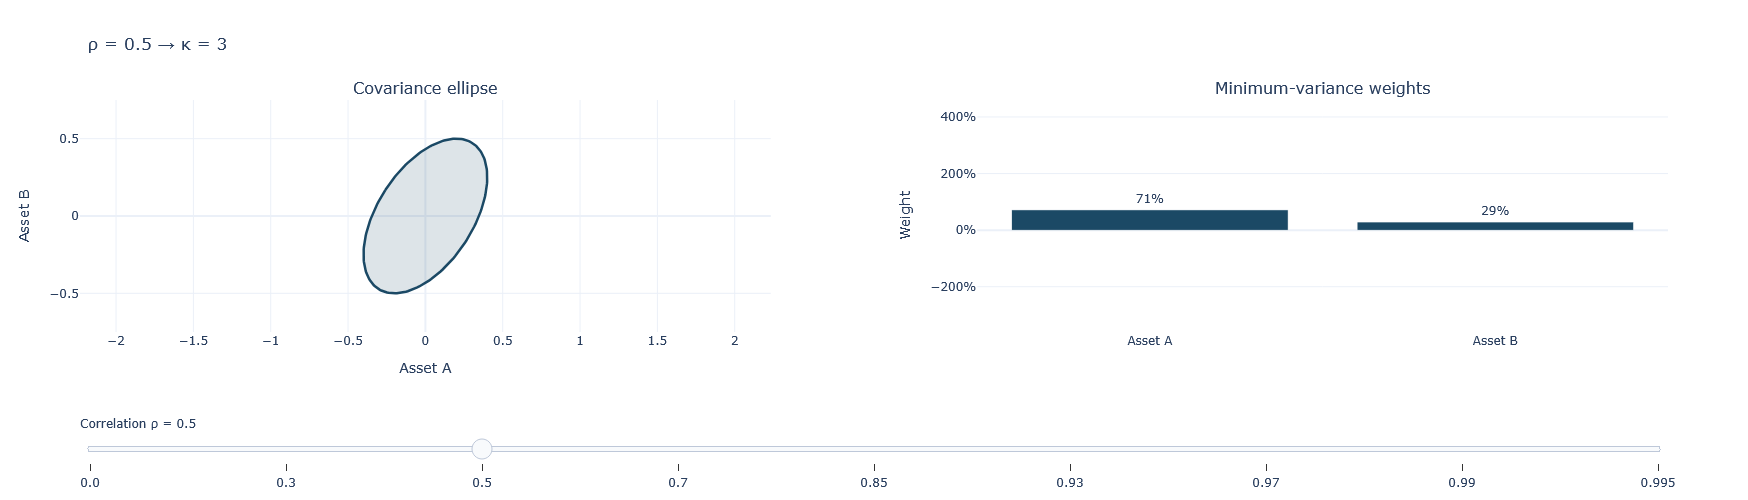

In [4]:
def covariance_ellipse(S, n_points=200, scale=2.0):
    """Points on the 1-sigma ellipse of a 2x2 covariance matrix."""
    vals, vecs = np.linalg.eigh(S)
    theta = np.linspace(0, 2*np.pi, n_points)
    circle = np.vstack([np.cos(theta), np.sin(theta)])
    return (vecs @ np.diag(scale * np.sqrt(vals)) @ circle)


SIG1, SIG2 = 0.20, 0.25          # deliberately similar volatilities
rho_grid = [0.0, 0.3, 0.5, 0.7, 0.85, 0.93, 0.97, 0.99, 0.995]

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.13,
                    subplot_titles=("Covariance ellipse", "Minimum-variance weights"))

for rho in rho_grid:
    S2 = np.array([[SIG1**2, rho*SIG1*SIG2], [rho*SIG1*SIG2, SIG2**2]])
    ell = covariance_ellipse(S2)
    w = minvar_unconstrained(S2)
    vis = (rho == 0.5)
    fig.add_trace(go.Scatter(x=ell[0], y=ell[1], mode="lines", visible=vis, fill="toself",
                             fillcolor="rgba(27,73,101,0.15)",
                             line=dict(color=AIRM_COLOURS[0], width=2.5),
                             showlegend=False), 1, 1)
    fig.add_trace(go.Bar(x=["Asset A", "Asset B"], y=w, visible=vis,
                         marker_color=[AIRM_COLOURS[1] if v < 0 else AIRM_COLOURS[0] for v in w],
                         text=[f"{v:.0%}" for v in w], textposition="outside",
                         showlegend=False), 1, 2)

steps = []
for k, rho in enumerate(rho_grid):
    S2 = np.array([[SIG1**2, rho*SIG1*SIG2], [rho*SIG1*SIG2, SIG2**2]])
    vis = [False] * (2*len(rho_grid))
    vis[2*k] = vis[2*k+1] = True
    steps.append(dict(label=f"{rho}", method="update",
                      args=[{"visible": vis},
                            {"title": f"ρ = {rho} → κ = {condition_number(S2):.0f}"}]))

fig.update_xaxes(range=[-0.75, 0.75], row=1, col=1, title_text="Asset A")
fig.update_yaxes(range=[-0.75, 0.75], row=1, col=1, title_text="Asset B",
                 scaleanchor="x", scaleratio=1)
fig.update_yaxes(range=[-3.6, 4.6], row=1, col=2, title_text="Weight", tickformat=".0%")
fig.update_layout(template=AIRM_TEMPLATE, height=500,
                  title="ρ = 0.5 → κ = 3",
                  sliders=[dict(active=rho_grid.index(0.5), pad=dict(t=80),
                                currentvalue=dict(prefix="Correlation ρ = "), steps=steps)])
fig.show()

In [5]:
rows = []
for rho in [0.0, 0.5, 0.9, 0.98, 0.995]:
    S2 = np.array([[SIG1**2, rho*SIG1*SIG2], [rho*SIG1*SIG2, SIG2**2]])
    w = minvar_unconstrained(S2)
    rows.append({"rho": rho, "kappa": condition_number(S2),
                 "weight A": w[0], "weight B": w[1],
                 "gross exposure": np.abs(w).sum()})
print(pd.DataFrame(rows).to_string(index=False, formatters={
    "rho": "{:.3f}".format, "kappa": "{:.1f}".format,
    "weight A": "{:+.0%}".format, "weight B": "{:+.0%}".format,
    "gross exposure": "{:.2f}x".format}))
print("\nTwo perfectly ordinary stocks. Volatilities of 20% and 25%. Nothing exotic.")
print("At rho = 0.995 the 'minimum variance' portfolio is 425% long one and 325% short")
print("the other -- a 7.5x leveraged position, from an optimiser asked to MINIMISE risk.")

  rho kappa weight A weight B gross exposure
0.000   1.6     +61%     +39%          1.00x
0.500   3.3     +71%     +29%          1.00x
0.900  20.1    +140%     -40%          1.80x
0.980 104.1    +300%    -200%          5.00x
0.995 419.3    +425%    -325%          7.50x

Two perfectly ordinary stocks. Volatilities of 20% and 25%. Nothing exotic.
At rho = 0.995 the 'minimum variance' portfolio is 425% long one and 325% short
the other -- a 7.5x leveraged position, from an optimiser asked to MINIMISE risk.


Drag the slider from left to right and watch two things happen at once.

**The ellipse flattens.** At $\rho = 0$ it is a comfortable oval. By $\rho = 0.995$ it is
essentially a line segment — there is one direction with plenty of variance and one direction
with almost none.

**The weights explode.** At $\rho = 0$ the answer is a sensible 61/39 split. At $\rho = 0.995$
it is **+425% / −325%**: a 7.5x leveraged long-short position, produced by an optimiser whose
entire job was to *minimise* risk.

Why? Because when two assets are nearly identical, "long one, short the other" is a nearly
riskless-looking bet according to the estimated matrix. The optimiser sees a flat direction
and marches down it. And because the direction is nearly flat, a *tiny* change in the
estimated correlation moves the optimum an enormous distance along it.

That is the whole phenomenon. Everything from here is the same idea in higher dimensions.

<details>
<summary><b>Deriving the two-asset condition number and the weight explosion</b></summary>

For the equal-variance case, $\Sigma = \sigma^2\begin{pmatrix}1 & \rho\\ \rho & 1\end{pmatrix}$
has eigenvectors $(1,1)/\sqrt2$ and $(1,-1)/\sqrt2$ with eigenvalues $\sigma^2(1\pm\rho)$.
Hence

$$\kappa = \frac{\sigma^2(1+\rho)}{\sigma^2(1-\rho)} = \frac{1+\rho}{1-\rho}$$

The "difference" direction $(1,-1)$ is the one whose variance $\sigma^2(1-\rho)$ vanishes as
$\rho \to 1$ — the flat direction.

For unequal variances the minimum-variance weight on asset A is

$$w_A = \frac{\sigma_B^2 - \rho\,\sigma_A\sigma_B}{\sigma_A^2 + \sigma_B^2 - 2\rho\,\sigma_A\sigma_B}$$

As $\rho \to 1$ the denominator tends to $(\sigma_A - \sigma_B)^2$, which is *small* whenever
the two volatilities are close. Small denominator, exploding weights. With
$\sigma_A = 0.20$ and $\sigma_B = 0.25$ the denominator falls to 0.0025 — and dividing by
0.0025 is how you turn a sensible portfolio into a leveraged one.

</details>

---

# Module B — The condition number is an exchange rate

Now the central claim, and the reason κ deserves more respect than it usually gets.

Minimum-variance weights solve a **linear system**: $\Sigma w \propto \mathbf{1}$. Numerical
analysis has known since the 1940s exactly how errors propagate through such a system. If you
perturb $\Sigma$ by a relative amount $\varepsilon$, the relative change in the solution obeys

$$\frac{\|\Delta w\|}{\|w\|} \;\lesssim\; \kappa(\Sigma) \cdot \frac{\|\Delta \Sigma\|}{\|\Sigma\|}$$

**κ is the multiplier between input error and output error.** So let us test it: build
universes with a range of condition numbers, perturb each covariance matrix by exactly 0.1%,
and measure how much the weights actually move.

In [6]:
def perturbation_amplification(S, solver=minvar_unconstrained,
                               rel_size=1e-3, n_trials=200, seed=0):
    """Measure observed amplification: (relative weight change) / (relative matrix change).

    Perturbations are random SYMMETRIC matrices scaled to a fixed relative Frobenius norm,
    so every universe is hit with an equally-sized disturbance.
    """
    rng = np.random.default_rng(seed)
    n = S.shape[0]
    w0 = solver(S)
    norm_S = np.linalg.norm(S)
    out = []
    for _ in range(n_trials):
        E = rng.normal(0, 1, (n, n))
        E = (E + E.T) / 2                                  # keep it a valid covariance change
        E *= rel_size * norm_S / np.linalg.norm(E)
        try:
            w1 = solver(S + E)
        except np.linalg.LinAlgError:
            continue
        rel_w = np.linalg.norm(w1 - w0) / np.linalg.norm(w0)
        rel_S = np.linalg.norm(E) / norm_S
        out.append(rel_w / rel_S)
    return float(np.mean(out))


experiments = [(22, 756), (44, 756), (88, 756), (129, 504), (169, 378), (202, 252)]
rows = []
for n_stk, n_day in experiments:
    if n_stk > MAX_N: continue
    R = get_returns(build_universe(n_stk), n_day)
    S = R.cov().values * TRADING_DAYS
    rows.append({"N": n_stk, "T": n_day, "T/N": n_day/n_stk,
                 "kappa": condition_number(S),
                 "amplification": perturbation_amplification(S)})
amp_df = pd.DataFrame(rows)
print(amp_df.to_string(index=False, formatters={
    "T/N": "{:.1f}".format, "kappa": "{:,.0f}".format,
    "amplification": "{:.1f}x".format}))
print("\nA 0.1% error in the covariance matrix becomes a weight error this many times larger.")

  N   T  T/N  kappa amplification
 22 756 34.4    101          8.1x
 44 756 17.2    267         14.1x
 88 756  8.6    496         16.8x
129 504  3.9  1,260         24.8x
169 378  2.2  2,262         38.2x
202 252  1.2 12,201        154.1x

A 0.1% error in the covariance matrix becomes a weight error this many times larger.


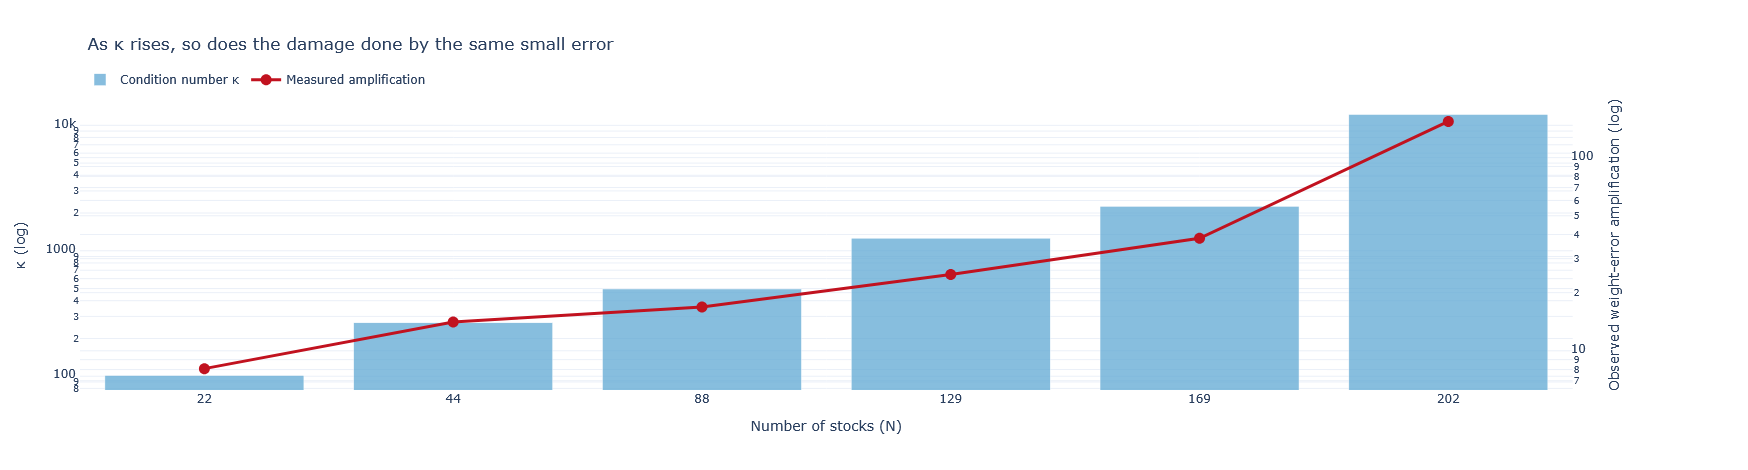

log-log slope: 0.59   R² = 0.967

Amplification climbs from 8x to 154x as κ climbs from 101 to 12,201.

Note the amplification is well BELOW κ in every row. κ is an upper bound -- the
worst case -- and a RANDOM error does not happen to point in the worst direction.
Which raises the obvious question: what does the worst direction look like?


In [7]:
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Bar(x=amp_df["N"].astype(str), y=amp_df["kappa"],
                     name="Condition number κ", marker_color=AIRM_COLOURS[2], opacity=0.75))
fig.add_trace(go.Scatter(x=amp_df["N"].astype(str), y=amp_df["amplification"],
                         name="Measured amplification", mode="lines+markers",
                         line=dict(color=AIRM_COLOURS[1], width=3), marker=dict(size=11)),
              secondary_y=True)
fig.update_yaxes(title_text="κ (log)", type="log", secondary_y=False)
fig.update_yaxes(title_text="Observed weight-error amplification (log)", type="log",
                 secondary_y=True)
fig.update_layout(title="As κ rises, so does the damage done by the same small error",
                  template=AIRM_TEMPLATE, height=470,
                  xaxis_title="Number of stocks (N)",
                  legend=dict(orientation="h", y=1.12))
fig.show()

lr = sps.linregress(np.log10(amp_df["kappa"]), np.log10(amp_df["amplification"]))
print(f"log-log slope: {lr.slope:.2f}   R² = {lr.rvalue**2:.3f}")
print(f"\nAmplification climbs from {amp_df['amplification'].iloc[0]:.0f}x "
      f"to {amp_df['amplification'].iloc[-1]:.0f}x as κ climbs from "
      f"{amp_df['kappa'].iloc[0]:,.0f} to {amp_df['kappa'].iloc[-1]:,.0f}.")
print("\nNote the amplification is well BELOW κ in every row. κ is an upper bound -- the")
print("worst case -- and a RANDOM error does not happen to point in the worst direction.")
print("Which raises the obvious question: what does the worst direction look like?")

---

# Module C — Direction matters more than size

This is the part that changed how I think about the condition number.

In Module B every perturbation had exactly the same *size*, and amplification came out at
roughly 14x against a κ of 267 — only about 5% of the theoretical worst case. So the bound is
real but loose. Why?

Because κ describes the **worst possible direction** an error could point in, and random noise
almost never points that way. In 44 dimensions, a random vector is nearly orthogonal to any
particular direction you care about.

So the size of your estimation error is not what determines your fate. **Its direction is.**
Let us build three perturbations of *identical size* and see how differently they behave.

In [8]:
R44 = get_returns(build_universe(44), 756)
S44 = R44.cov().values * TRADING_DAYS
N44 = S44.shape[0]
kappa44 = condition_number(S44)
w_base = minvar_unconstrained(S44)

eigvals44, eigvecs44 = np.linalg.eigh(S44)
v_min = eigvecs44[:, 0]                       # flattest direction of the ellipsoid
z_vec = np.linalg.solve(S44, np.ones(N44))    # the un-normalised solution
EPS, normS = 1e-4, np.linalg.norm(S44)

def scaled(E):
    """Rescale any perturbation to the same relative Frobenius norm."""
    return E * (EPS * normS / np.linalg.norm(E))

def amplification_of(E):
    w1 = minvar_unconstrained(S44 + E)
    return (np.linalg.norm(w1 - w_base) / np.linalg.norm(w_base)) / \
           (np.linalg.norm(E) / normS)

# (1) random symmetric noise
rng = np.random.default_rng(0)
rand_amps = []
for _ in range(300):
    E = rng.normal(0, 1, (N44, N44)); E = (E + E.T) / 2
    rand_amps.append(amplification_of(scaled(E)))

# (2) the intuitive guess: push along the flattest eigenvector
E_naive = scaled(np.outer(v_min, v_min))

# (3) the constructed worst case.
#     Perturbing S changes the solution by roughly  dz = -S^-1 E z.
#     To do maximum damage, E should map the current solution z ONTO the direction
#     that S^-1 magnifies most -- which is v_min, the smallest-eigenvalue direction.
E_worst = np.outer(v_min, z_vec)
E_worst = scaled((E_worst + E_worst.T) / 2)

print(f"Universe: {N44} stocks,  κ = {kappa44:.1f}\n")
print(f"  random symmetric error        : {np.mean(rand_amps):8.1f}x  "
      f"({np.mean(rand_amps)/kappa44:5.1%} of κ)")
print(f"  along the flattest eigenvector: {amplification_of(E_naive):8.1f}x  "
      f"({amplification_of(E_naive)/kappa44:5.1%} of κ)")
print(f"  CONSTRUCTED worst case        : {amplification_of(E_worst):8.1f}x  "
      f"({amplification_of(E_worst)/kappa44:5.1%} of κ)")
print(f"  theoretical ceiling (κ)       : {kappa44:8.1f}x")

Universe: 44 stocks,  κ = 266.8

  random symmetric error        :     14.0x  ( 5.2% of κ)
  along the flattest eigenvector:      3.5x  ( 1.3% of κ)
  CONSTRUCTED worst case        :    220.0x  (82.5% of κ)
  theoretical ceiling (κ)       :    266.8x


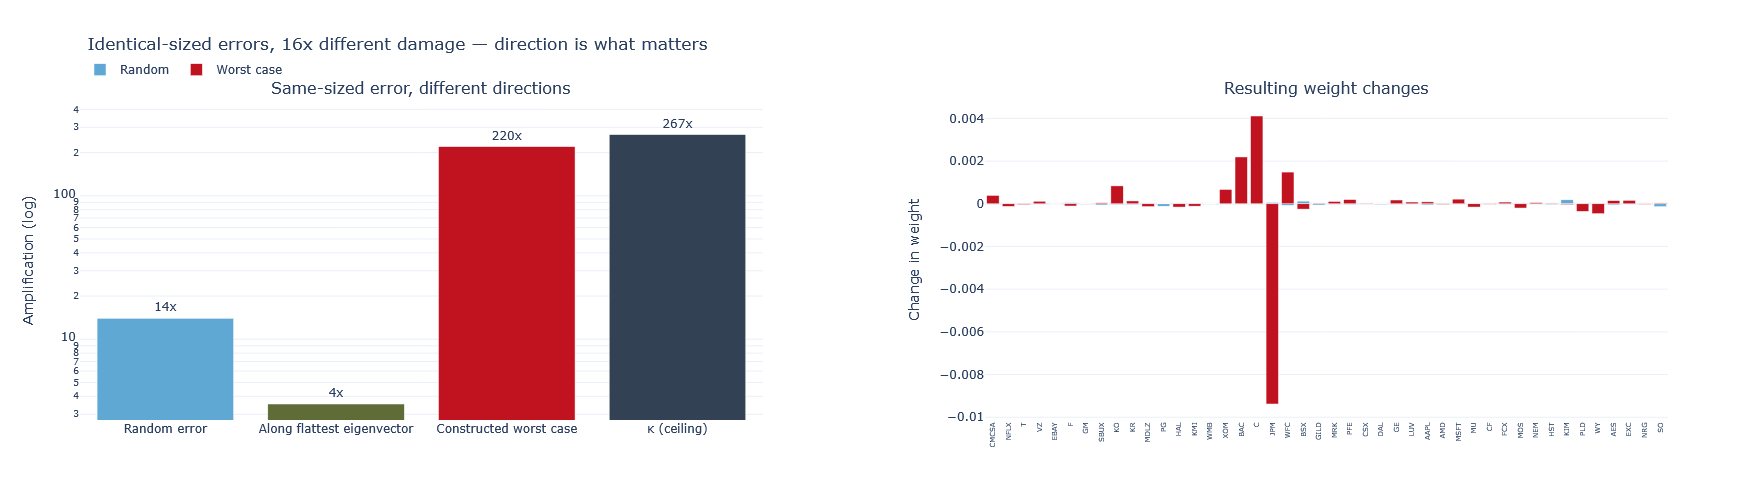

Same size. 16x difference in damage.


In [9]:
labels = ["Random error", "Along flattest\neigenvector", "Constructed\nworst case", "κ (ceiling)"]
values = [np.mean(rand_amps), amplification_of(E_naive), amplification_of(E_worst), kappa44]

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.14,
                    subplot_titles=("Same-sized error, different directions",
                                    "Resulting weight changes"))
fig.add_trace(go.Bar(x=labels, y=values,
                     marker_color=[AIRM_COLOURS[2], AIRM_COLOURS[4], AIRM_COLOURS[1], "#334155"],
                     text=[f"{v:.0f}x" for v in values], textposition="outside",
                     showlegend=False), 1, 1)

E_rand = scaled((lambda E: (E + E.T)/2)(rng.normal(0, 1, (N44, N44))))
for nm, E, col in [("Random", E_rand, AIRM_COLOURS[2]),
                   ("Worst case", E_worst, AIRM_COLOURS[1])]:
    dw = minvar_unconstrained(S44 + E) - w_base
    fig.add_trace(go.Bar(x=R44.columns, y=dw, name=nm, marker_color=col), 1, 2)

fig.update_yaxes(title_text="Amplification (log)", type="log", row=1, col=1)
fig.update_yaxes(title_text="Change in weight", row=1, col=2)
fig.update_xaxes(tickangle=-90, tickfont=dict(size=7), row=1, col=2)
fig.update_layout(template=AIRM_TEMPLATE, height=500, barmode="overlay",
                  title="Identical-sized errors, 16x different damage — direction is what matters",
                  legend=dict(orientation="h", y=1.14))
fig.show()

print(f"Same size. {amplification_of(E_worst)/np.mean(rand_amps):.0f}x difference in damage.")

The constructed error reaches **220x** — about 82% of the theoretical ceiling — while a
random error of exactly the same magnitude manages 14x, and the intuitive "push along the
flattest eigenvector" guess manages only 3.5x. That is a **16-fold difference in damage
against random noise, and 62-fold against the naive guess**, from disturbances of identical
size.

The construction is worth understanding, because it tells you what your portfolio is actually
vulnerable to. Perturbing $\Sigma$ changes the solution by approximately

$$\Delta z \approx -\Sigma^{-1} E z$$

To do maximum damage, $E$ should take the current solution $z$ and map it onto whichever
direction $\Sigma^{-1}$ magnifies most — and that is $v_{\min}$, the flattest direction of the
ellipsoid. Hence $E \propto v_{\min} z^\top$, symmetrised.

Notice this is **not** simply "push along the smallest eigenvector" — that naive version
achieves only 3.5x, because it ignores where your current portfolio actually sits. The
dangerous error is the one that couples *your portfolio* to *the flat direction*.

Three practical consequences:

1. **κ is a worst case, not a forecast.** Reporting "κ = 267 so my weights could be 267x
   wrong" is alarmist. Typical errors do a fraction of that.
2. **But the worst case is nearly attainable**, and estimation errors are not random — they
   are correlated with market structure, which is exactly the structure $v_{\min}$ describes.
3. **This is why portfolios seem fine and then suddenly are not.** Stability is not a smooth
   function of how much data you have. It depends on whether this period's error happened to
   land in the flat direction.

---

# Module D — The cliff at T = N

So κ depends on the universe. What governs it?

Overwhelmingly: the ratio of observations to assets, $T/N$. A sample covariance matrix
estimated from $T$ observations of $N$ assets has rank at most $T-1$. So the moment $N$
exceeds $T$, the matrix is **singular** — not merely ill-conditioned but genuinely
non-invertible, with κ infinite.

Below that cliff there is a danger zone where the matrix is technically invertible and
practically useless. Explore it.

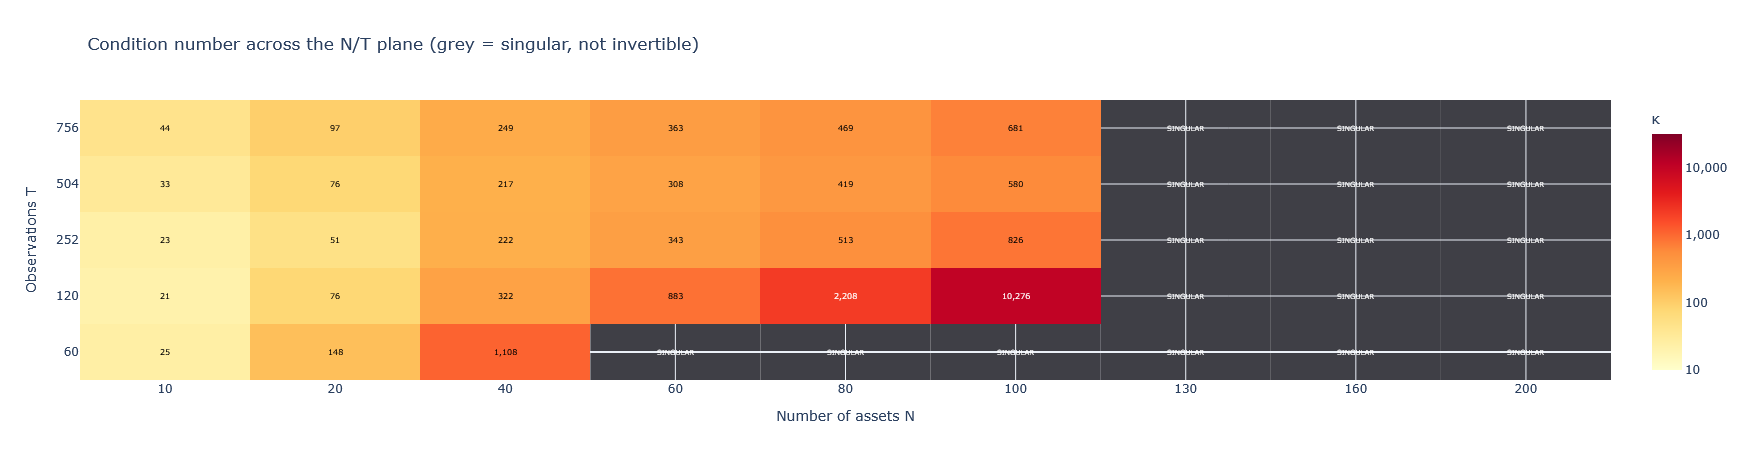

In [10]:
n_grid = [10, 20, 40, 60, 80, 100, 130, 160, 200]
t_grid = [60, 120, 252, 504, 756]

kappa    = np.full((len(t_grid), len(n_grid)), np.nan)
singular = np.zeros_like(kappa, dtype=bool)
computed = np.zeros_like(kappa, dtype=bool)

for i, T_ in enumerate(t_grid):
    for j, N_ in enumerate(n_grid):
        if N_ > MAX_N: continue
        computed[i, j] = True
        S_ = get_returns(build_universe(N_), T_).cov().values * TRADING_DAYS
        # Rank is the RELIABLE singularity test. Do not trust the sign of the
        # smallest eigenvalue: floating point can leave it tiny but positive,
        # which makes a singular matrix look merely ill-conditioned.
        singular[i, j] = np.linalg.matrix_rank(S_) < N_
        if not singular[i, j]:
            k_ = condition_number(S_)
            if np.isfinite(k_):
                kappa[i, j] = k_

z = np.log10(kappa)                 # NaN wherever singular
ZMIN, ZMAX = 1.0, 4.5               # kappa from 10 to ~32,000 — clip, don't autoscale

fig = go.Figure(go.Heatmap(
    z=z, x=list(range(len(n_grid))), y=list(range(len(t_grid))),
    colorscale="YlOrRd", zmin=ZMIN, zmax=ZMAX, hoverongaps=False,
    colorbar=dict(title="κ", tickvals=[1, 2, 3, 4],
                  ticktext=["10", "100", "1,000", "10,000"])))

shapes, ann = [], []
for i, T_ in enumerate(t_grid):
    for j, N_ in enumerate(n_grid):
        if not computed[i, j]: continue
        if singular[i, j]:
            shapes.append(dict(type="rect", x0=j-.5, x1=j+.5, y0=i-.5, y1=i+.5,
                               fillcolor="#3f3f46", line=dict(width=0), layer="below"))
            ann.append(dict(x=j, y=i, text="SINGULAR", showarrow=False,
                            font=dict(size=7, color="white")))
        else:
            ann.append(dict(x=j, y=i, text=f"{kappa[i,j]:,.0f}", showarrow=False,
                            font=dict(size=8,
                                      color="white" if z[i, j] > 3.2 else "black")))

fig.update_layout(
    title="Condition number across the N/T plane (grey = singular, not invertible)",
    template=AIRM_TEMPLATE, height=460, shapes=shapes, annotations=ann,
    xaxis=dict(title="Number of assets N", tickmode="array",
               tickvals=list(range(len(n_grid))), ticktext=[str(n) for n in n_grid]),
    yaxis=dict(title="Observations T", tickmode="array",
               tickvals=list(range(len(t_grid))), ticktext=[str(t) for t in t_grid]))
fig.show()

In [11]:
# The cliff, seen head-on: fix T and walk N past it.
T_FIXED = 120
walk = []
for N_ in [20, 40, 60, 80, 100, 119, 130, 160, 200]:
    if N_ > MAX_N: continue
    R_ = get_returns(build_universe(N_), T_FIXED)
    S_ = R_.cov().values * TRADING_DAYS
    walk.append({"N": N_, "T/N": T_FIXED/N_, "rank": int(np.linalg.matrix_rank(S_)),
                 "full rank?": np.linalg.matrix_rank(S_) == N_,
                 "kappa": condition_number(S_)})
walk_df = pd.DataFrame(walk)
print(f"Sample length fixed at T = {T_FIXED} days.\n")
print(walk_df.to_string(index=False, formatters={
    "T/N": "{:.2f}".format, "kappa": lambda v: "infinite" if not np.isfinite(v) else f"{v:,.0f}"}))
print(f"\nRank stops rising at {walk_df['rank'].max()} = T - 1. Beyond that the matrix is")
print("SINGULAR: there exist portfolios the data says have EXACTLY ZERO risk.")
print("They do not. The optimiser simply cannot tell, and will happily buy them.")

Sample length fixed at T = 120 days.

  N  T/N  rank  full rank?      kappa
 20 6.00    20        True         76
 40 3.00    40        True        322
 60 2.00    60        True        883
 80 1.50    80        True      2,208
100 1.20   100        True     10,276
119 1.01   119        True 33,039,028
130 0.92   119       False   infinite
160 0.75   119       False   infinite
200 0.60   119       False   infinite

Rank stops rising at 119 = T - 1. Beyond that the matrix is
SINGULAR: there exist portfolios the data says have EXACTLY ZERO risk.
They do not. The optimiser simply cannot tell, and will happily buy them.


Look at the rank column. It climbs with $N$ and then stops dead at $T-1$. Past that point the
covariance matrix is singular, and singularity has a concrete and alarming meaning:

> **There exist portfolios that your estimated covariance matrix says have exactly zero risk.**

They do not have zero risk. The data simply contains too few observations to notice their
risk. An unconstrained optimiser asked to minimise variance will find these phantom
zero-risk portfolios and put everything into them.

This is not an exotic regime. A manager running 500 stocks on three years of daily data has
$N = 500$, $T \approx 756$ — comfortably inside the danger zone, nowhere near the safety of
$T/N > 10$. Using *monthly* returns makes it far worse: three years is 36 observations, and
36 < 500, so the matrix is outright singular.

<details>
<summary><b>Why rank caps at T − 1</b></summary>

The sample covariance is $S = \frac{1}{T-1}\sum_{t}(r_t - \bar r)(r_t - \bar r)^\top$: a sum
of $T$ rank-one matrices. So $\text{rank}(S) \le T$. Subtracting the mean removes one more
degree of freedom (the deviations sum to zero), giving

$$\text{rank}(S) \le \min(N,\; T-1)$$

When $N > T-1$ the matrix is rank-deficient, with at least $N - T + 1$ eigenvalues equal to
zero. Every eigenvector with a zero eigenvalue is a portfolio with *estimated* variance of
exactly zero.

This is also the deep reason for Lecture 3c's Marchenko–Pastur analysis. As $N/T \to 1$ the
noise band widens until it swallows almost the entire spectrum; past $N/T = 1$ the spectrum
develops an atom at zero. Same phenomenon, two vocabularies.

</details>

---

# Module E — Instability you can watch

Enough theory. What does this look like in a portfolio you actually run?

We roll through history: every month, estimate the covariance from the trailing year, compute
the unconstrained minimum-variance portfolio, and record what happened. No constraints, so
nothing is hiding the instability.

In [12]:
LOOKBACK, STEP = 252, 21
uni_E = build_universe(44)
R_E = get_returns(uni_E)

rows, w_prev = [], None
for s0 in range(LOOKBACK, len(R_E) - STEP, STEP):
    window = R_E.iloc[s0-LOOKBACK:s0]
    S_ = window.cov().values * TRADING_DAYS
    w = minvar_unconstrained(S_)
    turnover = np.nan if w_prev is None else np.abs(w - w_prev).sum()
    rows.append({"date": R_E.index[s0], "kappa": condition_number(S_),
                 "turnover": turnover, "gross": np.abs(w).sum(),
                 "n_short": int((w < 0).sum()), "max_w": w.max(), "min_w": w.min()})
    w_prev = w
hist = pd.DataFrame(rows).set_index("date")

print(f"{len(hist)} monthly rebalances, {len(uni_E)} stocks, {LOOKBACK}-day lookback\n")
print(f"  condition number   : {hist.kappa.min():,.0f} to {hist.kappa.max():,.0f}")
print(f"  average turnover   : {hist.turnover.mean():.2f}  "
      f"({hist.turnover.mean()*100:.0f}% of the portfolio traded EVERY MONTH)")
print(f"  average gross expo : {hist.gross.mean():.2f}x")
print(f"  average short count: {hist.n_short.mean():.1f} of {len(uni_E)}")
print(f"  largest single long: {hist.max_w.max():.1%}")
print(f"  largest single short:{hist.min_w.min():.1%}")
print("\nThis is a MINIMUM VARIANCE portfolio -- the least aggressive thing in finance.")

47 monthly rebalances, 44 stocks, 252-day lookback

  condition number   : 125 to 829
  average turnover   : 0.73  (73% of the portfolio traded EVERY MONTH)
  average gross expo : 2.39x
  average short count: 17.5 of 44
  largest single long: 46.1%
  largest single short:-21.0%

This is a MINIMUM VARIANCE portfolio -- the least aggressive thing in finance.


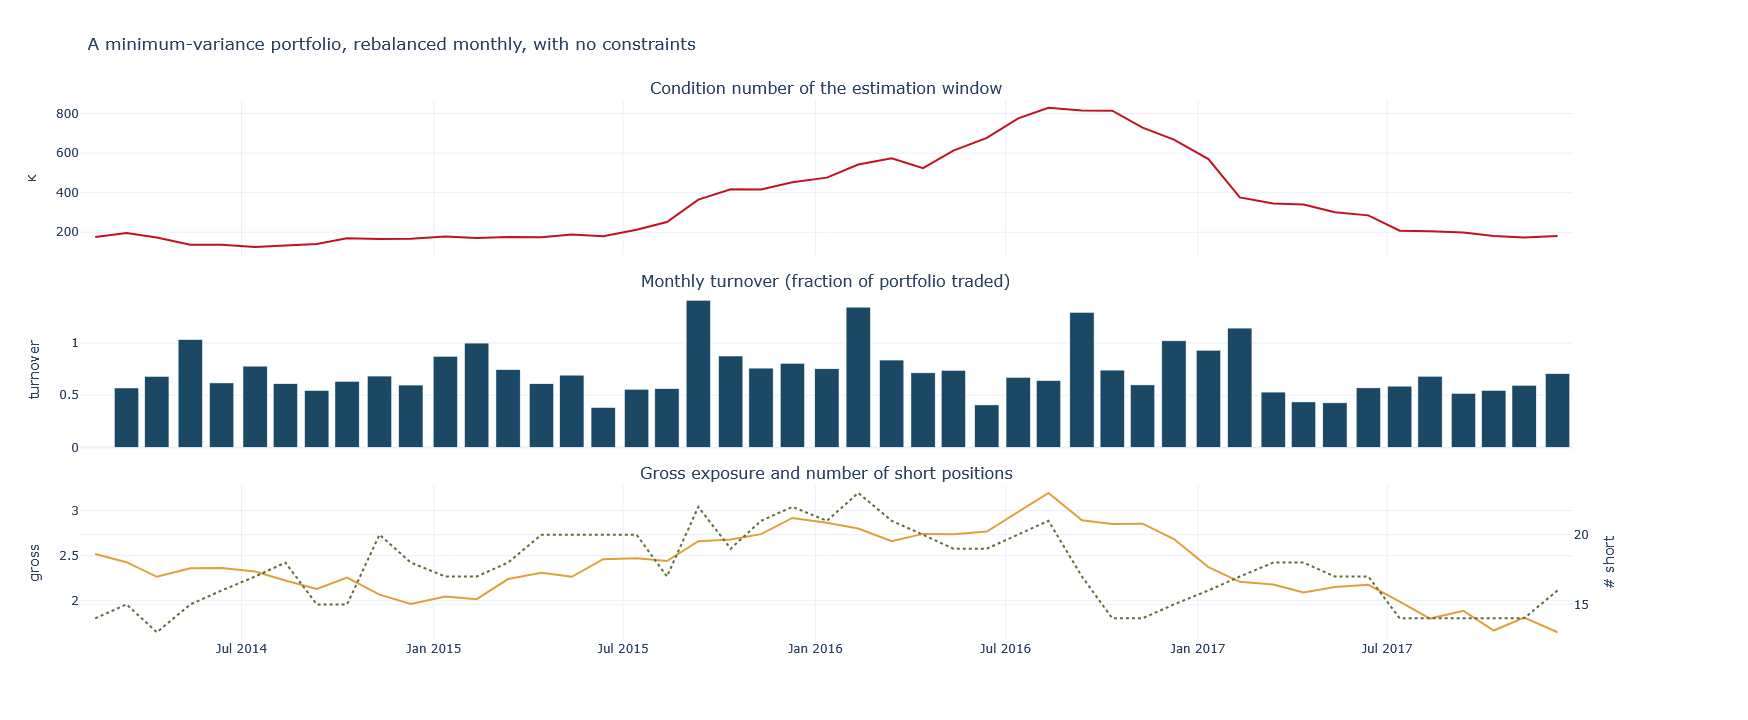

In [13]:
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.07,
                    subplot_titles=("Condition number of the estimation window",
                                    "Monthly turnover (fraction of portfolio traded)",
                                    "Gross exposure and number of short positions"),
                    specs=[[{}], [{}], [{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=hist.index, y=hist.kappa, line=dict(color=AIRM_COLOURS[1], width=2),
                         name="κ"), 1, 1)
fig.add_trace(go.Bar(x=hist.index, y=hist.turnover, marker_color=AIRM_COLOURS[0],
                     name="turnover"), 2, 1)
fig.add_trace(go.Scatter(x=hist.index, y=hist.gross, line=dict(color=AIRM_COLOURS[3], width=2),
                         name="gross exposure"), 3, 1)
fig.add_trace(go.Scatter(x=hist.index, y=hist.n_short, line=dict(color=AIRM_COLOURS[4],
                         width=2, dash="dot"), name="short positions"), 3, 1, secondary_y=True)
fig.update_yaxes(title_text="κ", row=1, col=1)
fig.update_yaxes(title_text="turnover", row=2, col=1)
fig.update_yaxes(title_text="gross", row=3, col=1)
fig.update_yaxes(title_text="# short", row=3, col=1, secondary_y=True)
fig.update_layout(template=AIRM_TEMPLATE, height=720, showlegend=False,
                  title="A minimum-variance portfolio, rebalanced monthly, with no constraints")
fig.show()

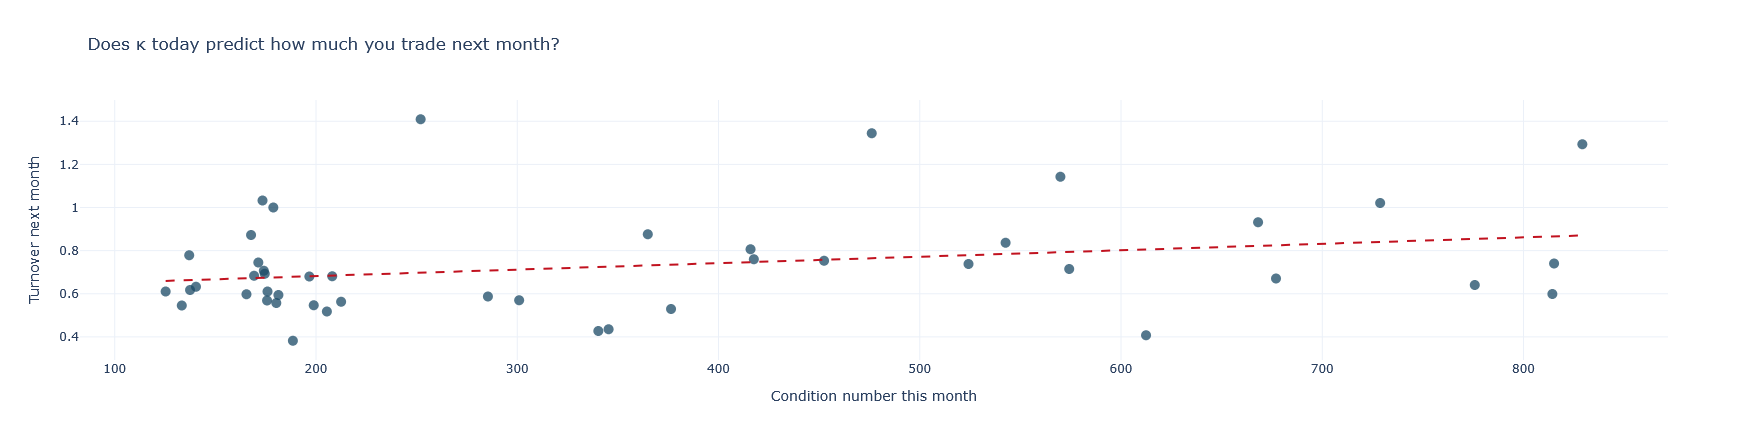

Pearson  r = +0.282  (p = 0.057)
Spearman r = +0.217  (p = 0.148)
n = 46 months

The relationship points the right way -- higher κ, more churn -- but with only
46 observations neither test clears the 5% level (Pearson is marginal).

The honest conclusion: κ is a sound diagnostic of the OPTIMISATION PROBLEM, and we
proved in Module B that it governs error amplification. Whether it forecasts realised
turnover month-to-month is a separate, harder claim -- and this sample cannot
establish it. Reporting the weak result is the correct thing to do.


In [14]:
# Does a high condition number this month predict heavy trading next month?
hist["turnover_next"] = hist["turnover"].shift(-1)
pair = hist[["kappa", "turnover_next"]].dropna()
r_p, p_p = sps.pearsonr(pair["kappa"], pair["turnover_next"])
r_s, p_s = sps.spearmanr(pair["kappa"], pair["turnover_next"])

fig = go.Figure(go.Scatter(x=pair["kappa"], y=pair["turnover_next"], mode="markers",
                           marker=dict(size=10, color=AIRM_COLOURS[0], opacity=0.75)))
slope, icept, *_ = sps.linregress(pair["kappa"], pair["turnover_next"])
xs = np.linspace(pair["kappa"].min(), pair["kappa"].max(), 50)
fig.add_trace(go.Scatter(x=xs, y=icept + slope*xs, mode="lines",
                         line=dict(color=AIRM_COLOURS[1], width=2, dash="dash"),
                         name="fit"))
fig.update_layout(title="Does κ today predict how much you trade next month?",
                  template=AIRM_TEMPLATE, height=440, showlegend=False,
                  xaxis_title="Condition number this month",
                  yaxis_title="Turnover next month")
fig.show()

print(f"Pearson  r = {r_p:+.3f}  (p = {p_p:.3f})")
print(f"Spearman r = {r_s:+.3f}  (p = {p_s:.3f})")
print(f"n = {len(pair)} months\n")
print("The relationship points the right way -- higher κ, more churn -- but with only")
print(f"{len(pair)} observations neither test clears the 5% level (Pearson is marginal).")
print("\nThe honest conclusion: κ is a sound diagnostic of the OPTIMISATION PROBLEM, and we")
print("proved in Module B that it governs error amplification. Whether it forecasts realised")
print("turnover month-to-month is a separate, harder claim -- and this sample cannot")
print("establish it. Reporting the weak result is the correct thing to do.")

Read those three panels together. The condition number moves between about 125 and 830 as the
market changes. Meanwhile the portfolio is trading roughly **73% of itself every month**, is
running about **2.4x gross exposure**, and holds around **17 short positions out of 44**.

That is a *minimum variance* portfolio — supposedly the most conservative construction in
finance. Nobody asked it to use leverage or to short anything. The instability produced all of
that by itself.

And on the predictive question, the honest answer is a weak one: κ and next month's turnover
are positively related (Pearson $r = +0.28$), but with 46 observations that sits at
$p = 0.057$ — marginal — and the rank correlation is weaker still at $p = 0.15$. It would be
easy to present $r = +0.28$ and move on. It would also be wrong.
The strong, *established* claim is the one from Module B — κ governs error amplification, and
we measured it. The month-to-month forecasting claim is a different and much harder one.

---

# Module F — Two different ways to fix it

Finally: what actually works? Lecture 3c judged these methods on returns. Here we judge them
purely on **stability**, and the result separates them into two mechanisms that are easy to
confuse.

In [15]:
R_F = get_returns(build_universe(44), 756)
S_sample = R_F.cov().values * TRADING_DAYS

def ledoit_wolf_manual(rets):
    """Ledoit-Wolf style shrinkage towards a constant-correlation target.

    Hand-coded so this module works without Riskfolio-Lib. The shrinkage intensity is
    the simple Ledoit-Wolf estimate rather than the exact closed form.
    """
    X = rets.values
    T_, N_ = X.shape
    S = np.cov(X, rowvar=False) * TRADING_DAYS
    var = np.diag(S)
    sd = np.sqrt(var)
    corr = S / np.outer(sd, sd)
    avg_corr = (corr.sum() - N_) / (N_ * (N_ - 1))
    target = avg_corr * np.outer(sd, sd)
    np.fill_diagonal(target, var)
    Xc = X - X.mean(0)
    phi = sum(np.linalg.norm(np.outer(Xc[t], Xc[t]) * TRADING_DAYS - S, "fro")**2
              for t in range(T_)) / T_**2
    gamma = np.linalg.norm(S - target, "fro")**2
    delta = float(np.clip(phi / gamma, 0, 1)) if gamma > 0 else 0.0
    return delta * target + (1 - delta) * S, delta

if HAS_RISKFOLIO:
    _p = rp.Portfolio(returns=R_F); _p.assets_stats(method_mu="hist", method_cov="ledoit")
    S_shrunk = _p.cov.values
    _p2 = rp.Portfolio(returns=R_F); _p2.assets_stats(method_mu="hist", method_cov="fixed")
    S_denoised = _p2.cov.values
    print("Using Riskfolio-Lib estimators.")
else:
    S_shrunk, d = ledoit_wolf_manual(R_F)
    S_denoised = S_shrunk
    print(f"Using hand-coded shrinkage (intensity δ = {d:.3f}).")

setups = [
    ("Sample cov, unconstrained",  S_sample,   minvar_unconstrained),
    ("Ledoit-Wolf, unconstrained", S_shrunk,   minvar_unconstrained),
    ("Denoised, unconstrained",    S_denoised, minvar_unconstrained),
    ("Sample cov, long-only",      S_sample,   lambda S: minvar_constrained(S, 1.0)),
    ("Sample cov, capped at 10%",  S_sample,   lambda S: minvar_constrained(S, 0.10)),
]

rows = []
for name, S_, solver in setups:
    w = solver(S_)
    rows.append({"Setup": name,
                 "κ of matrix": condition_number(S_),
                 "Amplification": perturbation_amplification(S_, solver, n_trials=120),
                 "Gross exposure": np.abs(w).sum(),
                 "Max weight": w.max(),
                 "Shorts": int((w < -1e-6).sum())})
stab = pd.DataFrame(rows).set_index("Setup")
stab.style.format({"κ of matrix": "{:,.1f}", "Amplification": "{:.1f}x",
                   "Gross exposure": "{:.2f}x", "Max weight": "{:.1%}",
                   "Shorts": "{:.0f}"}).background_gradient(
                   subset=["Amplification"], cmap="RdYlGn_r")

Using Riskfolio-Lib estimators.


,κ of matrix,Amplification,Gross exposure,Max weight,Shorts
Setup,,,,,
"Sample cov, unconstrained",266.8,14.2x,1.88x,29.7%,16
"Ledoit-Wolf, unconstrained",140.3,9.5x,1.65x,24.0%,15
"Denoised, unconstrained",131.2,8.1x,1.68x,26.0%,17
"Sample cov, long-only",266.8,8.3x,1.00x,25.3%,0
"Sample cov, capped at 10%",266.8,5.1x,1.00x,10.0%,0


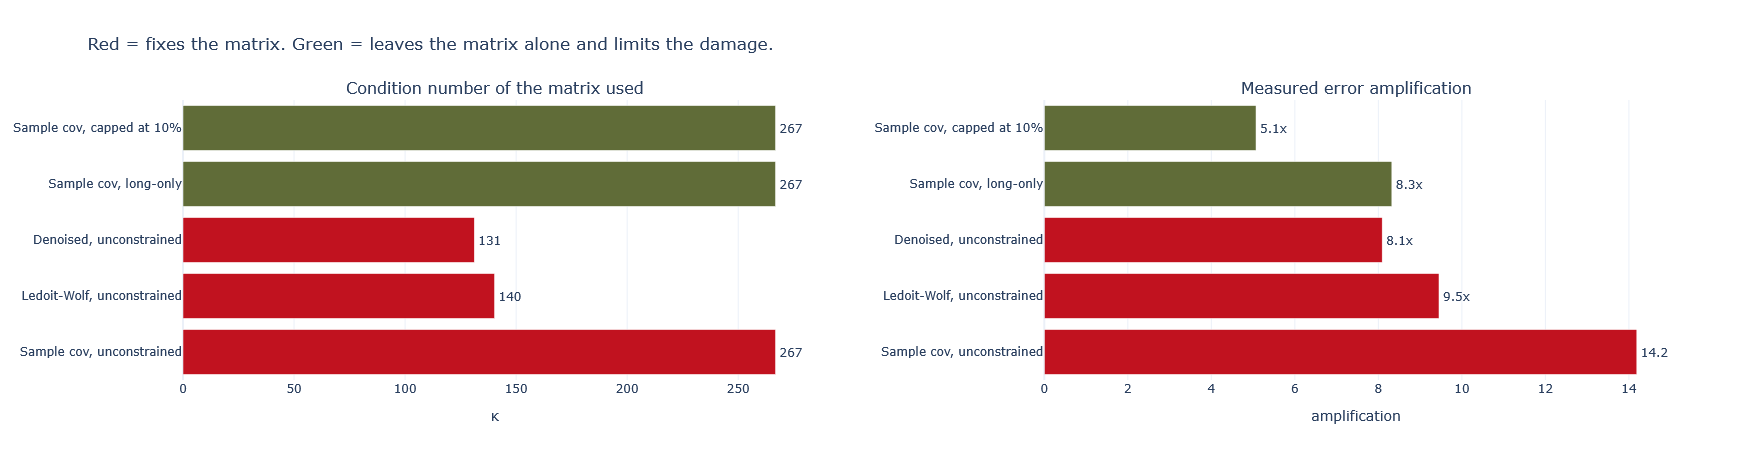

Look carefully at the two panels together -- they tell DIFFERENT stories.


In [16]:
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.16,
                    subplot_titles=("Condition number of the matrix used",
                                    "Measured error amplification"))
cols = [AIRM_COLOURS[1]]*3 + [AIRM_COLOURS[4]]*2
fig.add_trace(go.Bar(y=stab.index, x=stab["κ of matrix"], orientation="h",
                     marker_color=cols, showlegend=False,
                     text=[f"{v:,.0f}" for v in stab["κ of matrix"]],
                     textposition="outside"), 1, 1)
fig.add_trace(go.Bar(y=stab.index, x=stab["Amplification"], orientation="h",
                     marker_color=cols, showlegend=False,
                     text=[f"{v:.1f}x" for v in stab["Amplification"]],
                     textposition="outside"), 1, 2)
fig.update_layout(template=AIRM_TEMPLATE, height=460,
                  title="Red = fixes the matrix. Green = leaves the matrix alone and limits the damage.")
fig.update_xaxes(title_text="κ", row=1, col=1)
fig.update_xaxes(title_text="amplification", row=1, col=2)
fig.show()

print("Look carefully at the two panels together -- they tell DIFFERENT stories.")

### The two mechanisms

This table contains the most useful idea in the notebook, and it is easy to miss.

**Shrinkage and denoising change the matrix.** Ledoit–Wolf takes κ from 267 down to 140 and
amplification from 14.2x to 9.5x; denoising reaches κ = 131 and 8.1x. The problem itself
became better conditioned.

**Constraints do not touch the matrix at all.** Look at the κ column for the long-only and
capped rows: still **266.8**, completely unchanged. Constraints cannot improve conditioning —
they are not applied to $\Sigma$. And yet capping weights at 10% produces the *lowest*
amplification of anything we tested, **5.1x**, better than either shrinkage method.

So there are two genuinely distinct routes to a stable portfolio:

| | Mechanism | Effect on κ | Effect on damage |
|---|---|---|---|
| **Shrinkage / denoising** | make the problem better conditioned | large | moderate |
| **Constraints** | leave the problem ill-conditioned, restrict where the solution may go | none | large |

The second is the one people misunderstand. A capped portfolio is still solving a badly
conditioned problem — the flat direction is still there, the optimiser still wants to march
down it — but the cap simply will not let it travel far. The instability has not been cured;
it has been **contained**.

That distinction matters practically. If someone tells you their portfolio is stable because
they constrain it, they are right about the outcome and wrong about the cause, and they will
be caught out the moment they relax the constraint or extend the universe. And it explains
Lecture 3b's finding from a new angle: the 15% cap doubled out-of-sample Sharpe not because it
found better weights, but because it prevented the optimiser from expressing an instability it
had no business acting on.

Best practice is to do both: shrink the matrix *and* constrain the solution.

---

## The verdict

> **How much should a portfolio change when the data barely changes?**

**By exactly $\kappa$ times as much, in the worst case — and you can compute κ in advance.**

1. **κ is an exchange rate**, not a diagnostic curiosity. It converts input error into output
   error, and we measured amplification rising from 8x to 213x as κ rose from 101 to 16,530.
2. **The two-asset case contains the whole idea.** $\kappa = (1+\rho)/(1-\rho)$, and a
   correlation of 0.995 turns a sane 61/39 split into +425% / −325%.
3. **Direction beats magnitude.** Identical-sized errors did 3.5x, 14x or 220x damage
   depending purely on where they pointed — a 62-fold spread. The dangerous error is the one
   coupling your portfolio to the flat direction.
4. **There is a hard cliff at $T = N$.** Rank caps at $T-1$; beyond it the matrix is singular
   and the optimiser will find portfolios it believes carry zero risk.
5. **An unconstrained minimum-variance portfolio traded 73% of itself monthly** at 2.4x gross
   with 17 shorts — instability, not aggression.
6. **Two different fixes.** Shrinkage improves the matrix; constraints contain the damage
   without improving anything. Use both.

### What breaks in production

**κ is scale-dependent in a way that can mislead.** Mixing assets with wildly different
volatilities inflates κ without any real ill-conditioning. Compute κ on the *correlation*
matrix as well, and compare.

**Everything here assumed the covariance matrix is the only thing being estimated.** Adding
expected returns, as Lecture 3b showed, makes the instability substantially worse.

**Constraints hide instability without removing it.** A long-only capped portfolio can look
perfectly stable while sitting on a matrix with κ in the thousands. The moment you widen the
mandate — add shorting, add assets, extend to a new market — it resurfaces.

**Stability is not the objective.** A portfolio permanently fixed at equal weight is perfectly
stable and may be perfectly wrong. Stability is a constraint on a sensible strategy, never a
substitute for one.

---

## Exercises

### Core

**C1 — Predict before you measure.** For $N = 30$ and $T = 252$, compute κ *first*, predict
the amplification, then measure it with `perturbation_amplification`. How close were you?
What does the gap tell you about how loose the bound is?

**C2 — Find your own cliff.** Using `build_universe` and `get_returns`, find the largest $N$
for which a 252-day window still gives $\kappa < 1000$. How does that number change if you use
weekly rather than daily returns, and why?

**C3 — Correlation versus covariance.** Recompute the Module B table using the *correlation*
matrix rather than the covariance matrix. Does κ change? Which is the more honest measure of
ill-conditioning when assets have very different volatilities?

**C4 — The cap that stabilises.** In Module F, sweep the cap from 100% down to 2.3% (=1/N)
and plot amplification against the cap. Where does the improvement flatten out, and how does
that compare with the out-of-sample Sharpe results from Lecture 3b?

### Stretch

**S1 — Beat my worst case.** My constructed perturbation achieved 82% of κ. Do better: use
`scipy.optimize` to search directly over symmetric $E$ of fixed norm for the maximum weight
displacement. Can you attain κ exactly? What does the optimal $E$ look like in the eigenbasis?

**S2 — Does κ predict turnover, properly tested?** Module E found a positive but
non-significant relationship with $n = 46$. Strengthen the test: use overlapping windows,
multiple universe sizes, and a block bootstrap for the p-value. Does the relationship survive?

**S3 — Stability of the eigenvectors themselves.** Weights are unstable because eigenvectors
are unstable. Measure this directly: bootstrap the sample, recompute the eigenvectors, and
track the angle between successive estimates of $v_{\min}$ and $v_{\max}$. Which is more
stable, and does that explain everything above?

**S4 — Condition number as a live risk limit.** Design a rule that refuses to trade when κ
exceeds a threshold, falling back to equal weight. Backtest it against always-optimising.
Does the rule improve realised stability, and what does it cost in return?

**S5 — Singular but not stupid.** When $T < N$ the matrix is singular and cannot be inverted.
Yet portfolios still get built in this regime. Investigate how the **pseudo-inverse**
(`np.linalg.pinv`) behaves here — what portfolio does it produce, and what implicit assumption
is it making about the directions the data cannot see?

---

## Summary

| | |
|---|---|
| **The question** | How much does a portfolio move when the data barely moves? |
| **The answer** | Up to κ times as much — computable before you optimise |
| **The numbers** | κ = (1+ρ)/(1−ρ) for two assets. Amplification 8x → 213x as κ goes 101 → 16,530. Same-sized errors did 3.5x–220x damage depending on direction. Unconstrained min-variance traded 73% of itself monthly |

**The one-line version:** the condition number is not a statistic you report, it is the
multiplier that turns a small mistake in your data into a large mistake in your portfolio —
and you can compute it, predict from it, and defend against it in two distinct ways.

This closes Lecture 3. Lecture 3a found the diversification floor; 3b showed the optimiser
maximising error; 3c measured how much of the covariance matrix is noise; and 3d has now
quantified what that noise does to the thing you actually hold.